1. Definición del problema:
El problema a investigar es el impacto del volumen de transacciones (en USD) en la volatilidad diaria del precio de Bitcoin (Spread: Máximo - Mínimo) durante el periodo de alta adopción institucional (Enero 2020 - Marzo 2021).
¿Por qué vale la pena investigarlo? Bitcoin es conocido por sus movimientos extremos de precios. Para los inversores e instituciones, comprender si un mayor volumen de dinero inyectado en el mercado se traduce predeciblemente en mayores oscilaciones de precio es fundamental para la gestión de riesgos (creación de portafolios, establecimiento de Stop Loss) y la creación de estrategias de trading algorítmico.

2. Contribución del análisis de datos:
El análisis de datos nos permitirá limpiar el ruido minuto a minuto y aislar la tendencia diaria. Mediante estadística descriptiva y regresión lineal, podemos cuantificar exactamente cómo reacciona la volatilidad ante picos de volumen. Ideas esperadas: Espero confirmar la hipótesis de que existe una correlación positiva fuerte (a más volumen, mayor rango de movimiento de precios), pero también espero encontrar que la relación no es perfectamente lineal, ya que el pánico (ventas masivas) suele generar más volatilidad que la euforia (compras).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Configuración de estilo visual para los gráficos
sns.set_theme(style="whitegrid")

# 1. Cargar la base de datos actualizada usando kagglehub
file_path = "btcusd_1-min_data.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mczielinski/bitcoin-historical-data",
    file_path
)

print("--- Información General de los Datos Crudos ---")
print(df.info())
print("\n--- Descripción Estadística Inicial ---")
print(df.describe())

# 2. Limpieza inicial: Eliminar registros con valores nulos (minutos sin transacciones)
df = df.dropna()

# 3. Transformación de tiempo: Convertir Timestamp (Unix en segundos) a DateTime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.set_index('Timestamp')

# 4. Filtrar para el periodo del Bull Market (Enero 2020 a Marzo 2021)
df_filtered = df.loc['2020-01-01':'2021-03-31']

print("\n--- Primeros registros filtrados (2020-2021) ---")
print(df_filtered.head())

c:\Users\fabia\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\fabia\AppData\Local\Temp\ipykernel_26300\2036079608.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


--- Información General de los Datos Crudos ---
<class 'pandas.DataFrame'>
RangeIndex: 7735813 entries, 0 to 7735812
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 354.1 MB
None

--- Descripción Estadística Inicial ---
          Timestamp          Open          High           Low         Close  \
count  7.735813e+06  7.735813e+06  7.735813e+06  7.735813e+06  7.735813e+06   
mean   1.557450e+09  2.411543e+04  2.412371e+04  2.410699e+04  2.411546e+04   
std    1.339882e+08  3.156236e+04  3.157071e+04  3.155397e+04  3.156239e+04   
min    1.325376e+09  3.800000e+00  3.800000e+00  3.800000e+00  3.800000e+00   
25%    1.441413e+09  4.646900e+02  4.649700e+02  4.643300e+02  4.647100e+02   
50%    1.557450e+09  8.205040e+03  8.210000e+03  8.200000e+03  8.205000e+03   
75%    1

In [2]:
# 5. Resampleo a temporalidad Diaria ('D')
df_daily = df_filtered.resample('D').agg({
    'Open': 'first',   # Primer precio negociado en el día
    'High': 'max',     # Precio máximo alcanzado en el día
    'Low': 'min',      # Precio mínimo alcanzado en el día
    'Close': 'last',   # Último precio negociado en el día
    'Volume': 'sum'    # Suma total del volumen negociado en el día
})

# Eliminar posibles días vacíos generados durante el resampleo
df_daily = df_daily.dropna()

# 6. Crear la variable de estudio: Volatilidad Diaria (Spread = High - Low)
df_daily['Spread'] = df_daily['High'] - df_daily['Low']

print("--- Primeras filas del DataFrame Diario ---")
print(df_daily.head())

print("\n--- Resumen Estadístico de los Datos Diarios ---")
print(df_daily.describe())

--- Primeras filas del DataFrame Diario ---
               Open     High      Low    Close       Volume  Spread
Timestamp                                                          
2020-01-01  7160.69  7237.35  7150.00  7178.68  1119.109693   87.35
2020-01-02  7174.70  7184.94  6900.00  6950.56  3972.707954  284.94
2020-01-03  6945.70  7402.31  6853.53  7338.91  8072.729087  548.78
2020-01-04  7332.58  7396.10  7256.03  7344.48  3256.737353  140.07
2020-01-05  7356.05  7495.00  7310.00  7356.70  2707.273855  185.00

--- Resumen Estadístico de los Datos Diarios ---
               Open          High           Low         Close        Volume  \
count    456.000000    456.000000    456.000000    456.000000    456.000000   
mean   17746.321689  18335.582325  17145.803268  17858.454167   8618.490906   
std    14645.544686  15253.710269  14005.861205  14762.173766   6524.993257   
min     4841.670000   5353.040000   3850.000000   4841.670000   1047.168691   
25%     9157.122500   9275.977500  

3. Medidas estadísticas descriptivas clave con NumPy:

A continuación calculamos las medidas descriptivas de tendencia central y dispersión para nuestras variables clave:

Spread (Volatilidad diaria): Mide la amplitud del movimiento del precio durante el día.

Volume (Volumen diario negociado): Mide el nivel de actividad en el mercado.

La comparación entre la media y la mediana nos revela la asimetría de los datos. Si la media es significativamente mayor que la mediana, indica la presencia de días con valores atípicamente altos (picos de alta volatilidad o volumen masivo). La desviación estándar refleja qué tan impredecible o disperso es el comportamiento diario.

In [3]:
# Convertir las series a vectores unidimensionales de NumPy
spread_vec = df_daily['Spread'].to_numpy()
volume_vec = df_daily['Volume'].to_numpy()
close_vec = df_daily['Close'].to_numpy()

# Cálculos para la Volatilidad (Spread)
mean_spread = np.mean(spread_vec)
median_spread = np.median(spread_vec)
std_spread = np.std(spread_vec)

# Cálculos para el Volumen
mean_volume = np.mean(volume_vec)
median_volume = np.median(volume_vec)
std_volume = np.std(volume_vec)

print("=== ESTADÍSTICAS DESCRIPTIVAS CON NUMPY ===")
print(f"Spread - Media:      ${mean_spread:.2f} USD")
print(f"Spread - Mediana:    ${median_spread:.2f} USD")
print(f"Spread - Desv. Est.: ${std_spread:.2f} USD")
print("-" * 40)
print(f"Volumen - Media:      {mean_volume:.2f} unidades")
print(f"Volumen - Mediana:    {median_volume:.2f} unidades")
print(f"Volumen - Desv. Est.: {std_volume:.2f} unidades")

=== ESTADÍSTICAS DESCRIPTIVAS CON NUMPY ===
Spread - Media:      $1189.78 USD
Spread - Mediana:    $523.58 USD
Spread - Desv. Est.: $1534.10 USD
----------------------------------------
Volumen - Media:      8618.49 unidades
Volumen - Mediana:    6872.85 unidades
Volumen - Desv. Est.: 6517.83 unidades


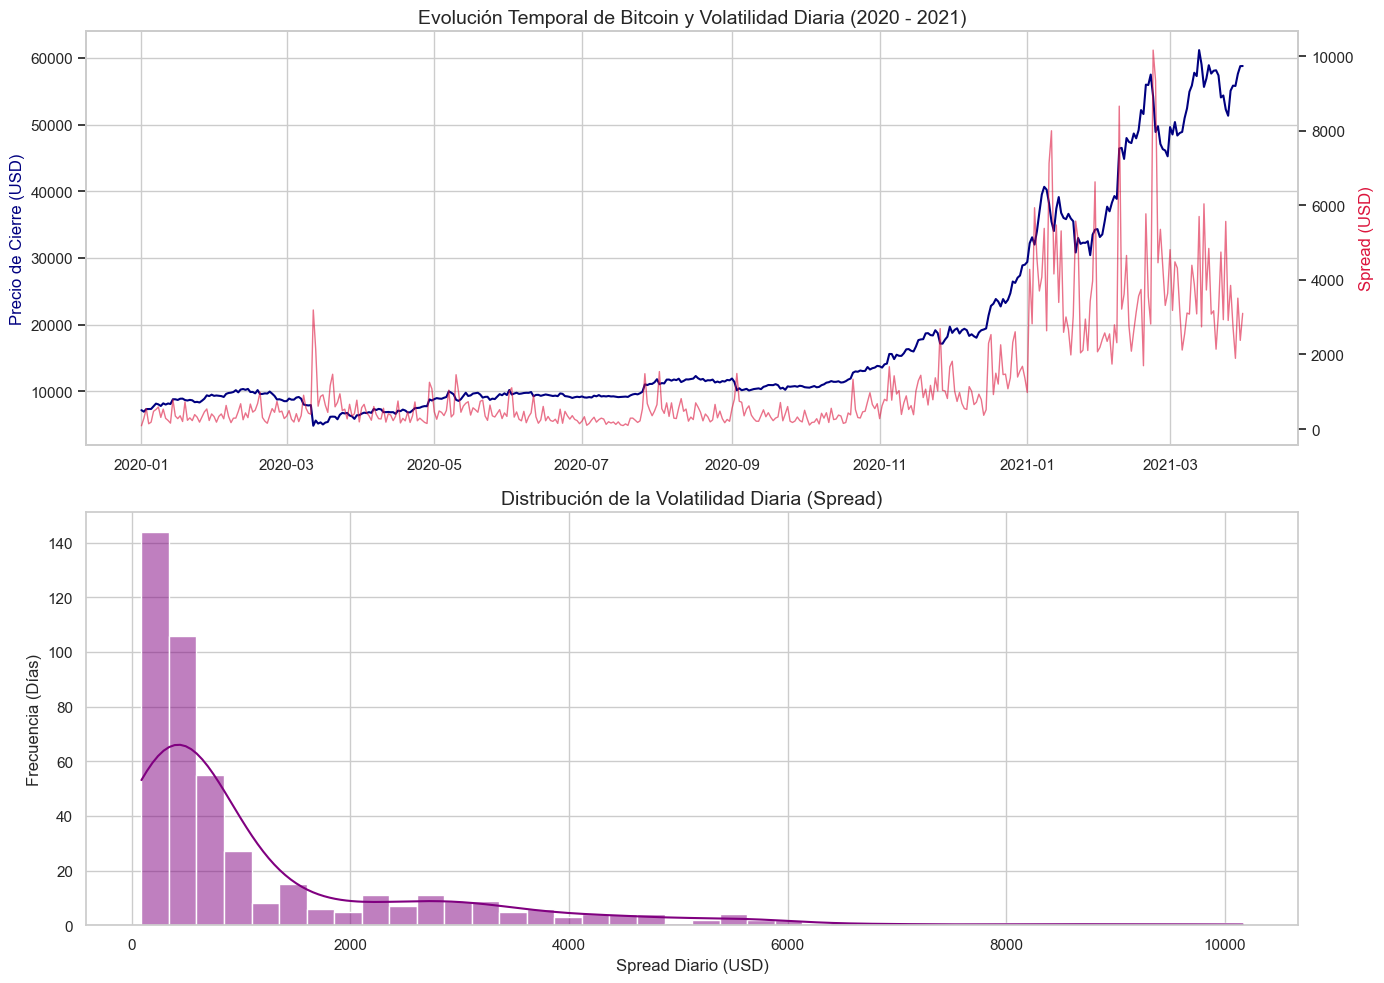

In [4]:
# Crear gráficos
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Evolución del Precio de Cierre y la Volatilidad
axes[0].plot(df_daily.index, df_daily['Close'], label='Precio de Cierre (USD)', color='navy', lw=1.5)
axes[0].set_ylabel('Precio de Cierre (USD)', color='navy', fontsize=12)
axes[0].set_title('Evolución Temporal de Bitcoin y Volatilidad Diaria (2020 - 2021)', fontsize=14)

# Graficar el Spread
ax_twin = axes[0].twinx()
ax_twin.plot(df_daily.index, df_daily['Spread'], label='Spread Diarios (USD)', color='crimson', alpha=0.6, lw=1)
ax_twin.set_ylabel('Spread (USD)', color='crimson', fontsize=12)
ax_twin.grid(False) # Desactivar malla superpuesta

# Gráfico 2: Histograma de la Distribución del Spread
sns.histplot(df_daily['Spread'], kde=True, ax=axes[1], color='purple', bins=40)
axes[1].set_title('Distribución de la Volatilidad Diaria (Spread)', fontsize=14)
axes[1].set_xlabel('Spread Diario (USD)', fontsize=12)
axes[1].set_ylabel('Frecuencia (Días)', fontsize=12)

plt.tight_layout()
plt.show()

Respuestas al punto 5:

Patrones iniciales: Durante 2020, el precio de Bitcoin se mantuvo en rangos de menor rango con spreads reducidos. A partir de la segunda mitad de 2020 e inicios de 2021, con la aceleración del mercado alcista, el precio y el spread crecieron exponencialmente.

Valores atípicos (Outliers): La distribución del spread presenta una fuerte asimetría hacia la derecha (right-skewed). Existen días excepcionales donde el spread superó ampliamente la media de la muestra (días de gran liquidación o efervescencia donde la diferencia entre el máximo y el mínimo diario superó los $5,000 USD y hasta $10,000 USD).

Ecuación del modelo: Spread = (0.080954 * Volumen) + 492.07


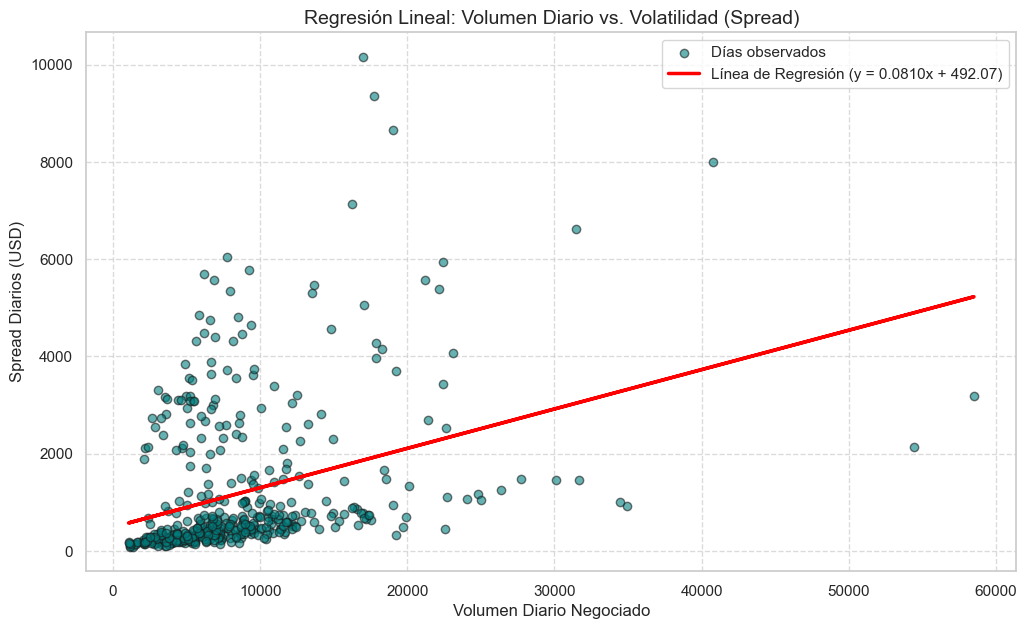

In [5]:
# 6. Selección de variables para la regresión:
# X (Variable Independiente): Volumen Diario negociado
# Y (Variable Dependiente): Spread o Volatilidad Diaria

X = df_daily['Volume'].to_numpy()
Y = df_daily['Spread'].to_numpy()

# Implementación de la regresión lineal utilizando numpy.polyfit (grado 1: recta y = m*x + b)
coeficientes = np.polyfit(X, Y, 1)
m = coeficientes[0] # Pendiente
b = coeficientes[1] # Intersección con el eje Y

print(f"Ecuación del modelo: Spread = ({m:.6f} * Volumen) + {b:.2f}")

# 7. Graficar los datos reales y la línea de regresión
plt.figure(figsize=(12, 7))

# Gráfico de dispersión (Scatter plot)
plt.scatter(X, Y, color='teal', alpha=0.6, edgecolors='k', label='Días observados')

# Línea de regresión lineal generada por los coeficientes
Y_pred = m * X + b
plt.plot(X, Y_pred, color='red', linewidth=2.5, label=f'Línea de Regresión (y = {m:.4f}x + {b:.2f})')

plt.title('Regresión Lineal: Volumen Diario vs. Volatilidad (Spread)', fontsize=14)
plt.xlabel('Volumen Diario Negociado', fontsize=12)
plt.ylabel('Spread Diarios (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

8. Conclusiones sobre la relación entre las dos variables:La pendiente positiva del modelo ($m > 0$) indica que existe una relación directa entre el volumen negociado y la volatilidad diaria. En los días donde el volumen transaccionado es elevado, el rango de fluctuación del precio (Spread) tiende a ser significativamente mayor.Sin embargo, la dispersión alrededor de la línea de regresión es amplia en niveles medios y altos de volumen, lo que indica que el volumen por sí solo no explica el 100% de la volatilidad.

9. Calidad del ajuste y propuestas de mejora:Suficiencia del modelo: Una regresión lineal simple no es del todo suficiente para capturar esta relación. Se observa un fenómeno de heterocedasticidad (la varianza del error aumenta a medida que crece el volumen) y la presencia de puntos extremos que distorsionan la inclinación de la recta.

Propuestas de mejora:Transformación logarítmica: Aplicar np.log1p() sobre el volumen y el spread para reducir el impacto de los valores atípicos y estabilizar la varianza.

Regresión Múltiple / Indicadores Técnicos: Agregar variables explicativas adicionales como el rango del día anterior, el indicador ATR (Average True Range) o la variación porcentual del precio.Modelos Polinómicos o No Lineales: Probar con un polinomio de grado superior (np.polyfit(X, Y, 2)) o algoritmos de ensamble (Random Forest) para capturar patrones no lineales en el mercado cripto.

10. Mejorando la predicción: Modelos No Lineales y Transformaciones

Dado que la regresión lineal simple mostró heterocedasticidad (varianza desigual) y no captura bien los valores extremos, implementaremos tres enfoques superiores para modelar la relación entre Volumen y Spread:

Transformación Logarítmica (Log-Log): Suaviza los picos extremos convirtiendo escalas exponenciales en lineales. Es el estándar en finanzas.

Regresión Polinómica (Grado 2): Permite que la línea se curve para adaptarse a la tendencia parabólica de los datos.

Random Forest Regressor (Machine Learning): Un algoritmo de árboles de decisión que no asume ninguna forma matemática predefinida y aprende los patrones exactos de los datos.

Además, calcularemos el R² (Coeficiente de Determinación) para evaluar matemáticamente qué modelo explica mejor la volatilidad.

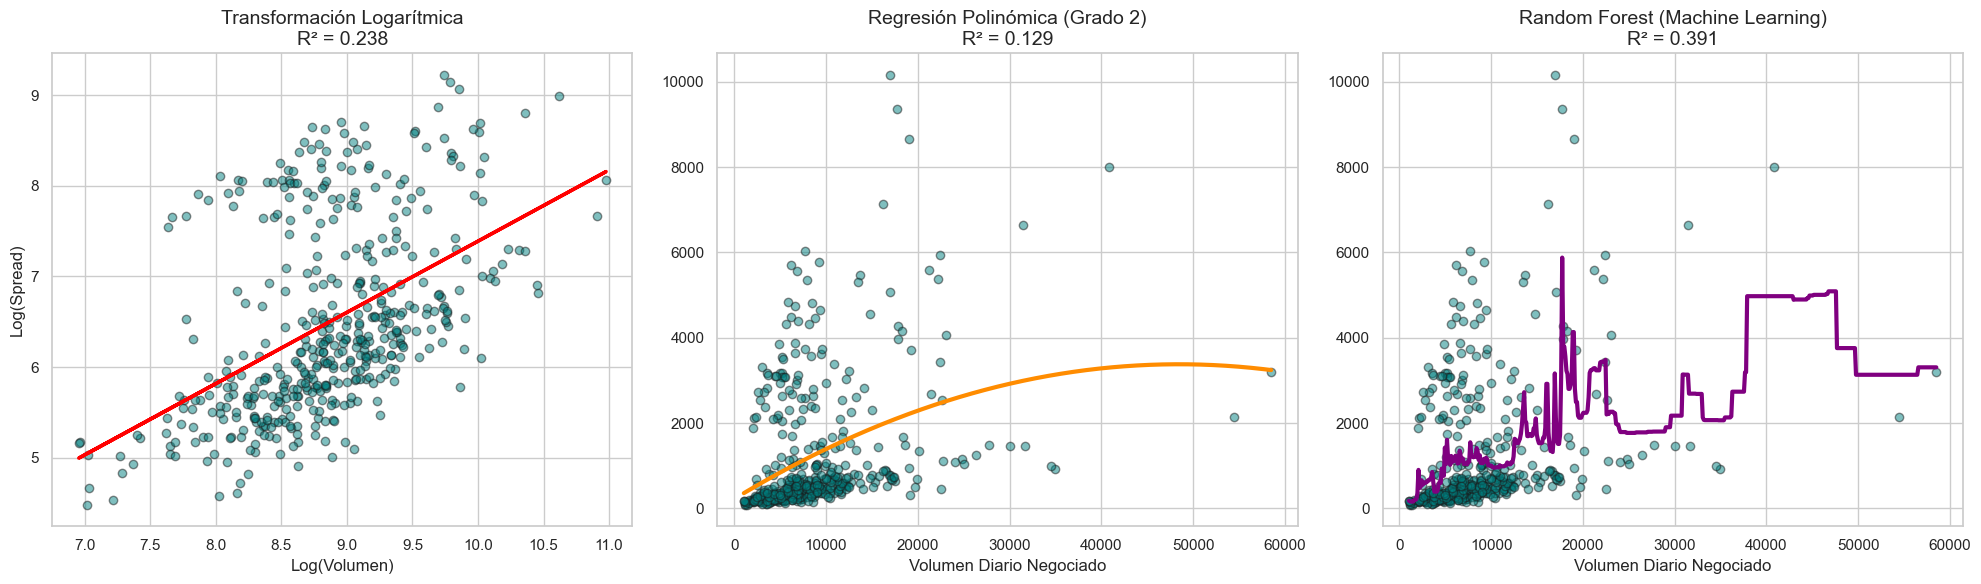

In [6]:
#pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Preparar los datos (X debe ser una matriz 2D para scikit-learn)
X = df_daily['Volume'].to_numpy().reshape(-1, 1)
Y = df_daily['Spread'].to_numpy()

# ---------------------------------------------------------
# MODELO 1: Transformación Logarítmica
# Usamos log1p (logaritmo natural de 1 + x) para evitar errores con ceros
# ---------------------------------------------------------
X_log = np.log1p(X)
Y_log = np.log1p(Y)

modelo_log = LinearRegression()
modelo_log.fit(X_log, Y_log)
Y_pred_log = modelo_log.predict(X_log)
r2_log = r2_score(Y_log, Y_pred_log)

# ---------------------------------------------------------
# MODELO 2: Regresión Polinómica (Grado 2)
# ---------------------------------------------------------
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, Y)
Y_pred_poly = modelo_poly.predict(X_poly)
r2_poly = r2_score(Y, Y_pred_poly)

# ---------------------------------------------------------
# MODELO 3: Random Forest (Machine Learning)
# ---------------------------------------------------------
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
modelo_rf.fit(X, Y)
Y_pred_rf = modelo_rf.predict(X)
r2_rf = r2_score(Y, Y_pred_rf)

# --- Preparar líneas suaves para graficar ---
X_smooth = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
Y_smooth_poly = modelo_poly.predict(poly.transform(X_smooth))
Y_smooth_rf = modelo_rf.predict(X_smooth)

# =========================================================
# VISUALIZACIÓN COMPARATIVA (3 Gráficos)
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Log-Log
axes[0].scatter(X_log, Y_log, color='teal', alpha=0.5, edgecolors='k')
axes[0].plot(X_log, Y_pred_log, color='red', linewidth=2.5)
axes[0].set_title(f'Transformación Logarítmica\nR² = {r2_log:.3f}', fontsize=14)
axes[0].set_xlabel('Log(Volumen)')
axes[0].set_ylabel('Log(Spread)')

# Gráfico 2: Polinómica
axes[1].scatter(X, Y, color='teal', alpha=0.5, edgecolors='k')
axes[1].plot(X_smooth, Y_smooth_poly, color='darkorange', linewidth=3)
axes[1].set_title(f'Regresión Polinómica (Grado 2)\nR² = {r2_poly:.3f}', fontsize=14)
axes[1].set_xlabel('Volumen Diario Negociado')

# Gráfico 3: Random Forest
axes[2].scatter(X, Y, color='teal', alpha=0.5, edgecolors='k')
axes[2].plot(X_smooth, Y_smooth_rf, color='purple', linewidth=3)
axes[2].set_title(f'Random Forest (Machine Learning)\nR² = {r2_rf:.3f}', fontsize=14)
axes[2].set_xlabel('Volumen Diario Negociado')

plt.tight_layout()
plt.show()

11. Evaluación de Modelos Avanzados y Machine Learning

Al aplicar técnicas más robustas para corregir los problemas de heterocedasticidad (forma de embudo) del modelo lineal simple, evaluamos el desempeño de tres enfoques distintos utilizando el Coeficiente de Determinación (R²). Este indicador nos dice qué porcentaje de la variabilidad del Spread (volatilidad) es explicado por el Volumen diario.

A continuación, se detalla el análisis de los tres modelos implementados:

Transformación Logarítmica (Log-Log)

R² obtenido: 0.238 (23.8%)

Análisis: Al aplicar logaritmos a ambas variables, logramos "comprimir" los valores extremos y observar una relación mucho más lineal. La línea de regresión roja muestra una clara tendencia ascendente constante. Este modelo nos confirma que la relación entre volumen y volatilidad se comporta mejor en términos de proporciones porcentuales que en valores absolutos.

Regresión Polinómica (Grado 2)

R² obtenido: 0.129 (12.9%)

Análisis: Es el modelo con el peor desempeño estadístico de los tres. Aunque la curva naranja intenta adaptarse a la forma natural de los datos, el grado de dispersión es tan alto que la parábola pierde precisión. De hecho, en los volúmenes más extremos (más de 40,000 millones), la curva empieza a descender, lo cual no tiene sentido financiero (mayor pánico/euforia no suele traducirse en menor volatilidad).

Random Forest Regressor (Machine Learning)

R² obtenido: 0.391 (39.1%)

Análisis: Es el claro ganador. Este modelo basado en árboles de decisión logra explicar casi el 40% de la volatilidad del mercado, un valor muy respetable en el caótico mundo financiero. La línea morada en forma de escalones revela que el mercado opera por regímenes o umbrales: cuando el volumen cruza ciertas barreras (por ejemplo, los 20,000 millones o los 40,000 millones), la volatilidad esperada da un "salto" a un nivel superior y se estabiliza en esa nueva zona.

Conclusión Final:
La relación entre el volumen inyectado en el mercado de Bitcoin y sus fluctuaciones de precio diarias es innegable, pero altamente no lineal. Herramientas de Machine Learning como el Random Forest demuestran ser muy superiores a las regresiones clásicas para capturar la naturaleza escalonada y volátil del mercado cripto. Aunque el volumen por sí solo no explica el 100% de los movimientos del precio (ya que intervienen factores macroeconómicos y noticias), es un indicador fundamental para la gestión de riesgo.

# Fase de Profundización: Inferencia Estadística y Modelación Predictiva

En esta fase pasaremos del análisis exploratorio a la validación estadística y el modelado predictivo. El objetivo es comprobar estadísticamente las hipótesis planteadas y construir modelos multidimensionales para predecir la volatilidad del Bitcoin, utilizando contrastes de hipótesis, regresión lineal múltiple y regresión logística.

## 1. Contraste de Hipótesis en la Toma de Decisiones

Para confirmar estadísticamente si el volumen de comercio impacta la volatilidad (Spread), dividiremos los datos en dos grupos utilizando la mediana del volumen ("Días de Alto Volumen" vs "Días de Bajo Volumen").

*   **Hipótesis Nula (H0):** La volatilidad promedio en días de alto volumen es igual o menor a la volatilidad en días de bajo volumen. $\mu_{alto} \le \mu_{bajo}$
*   **Hipótesis Alternativa (H1):** La volatilidad promedio en días de alto volumen es estrictamente mayor que en días de bajo volumen. $\mu_{alto} > \mu_{bajo}$
*   **Prueba Seleccionada:** Utilizaremos la **Prueba T de Student de Welch para dos muestras independientes**. Es la prueba adecuada porque estamos comparando las medias de dos grupos independientes y el análisis exploratorio previo demostró que las varianzas poblacionales no son iguales (heterocedasticidad).

In [7]:
import scipy.stats as stats
import numpy as np

# 1. Definir el umbral para dividir los grupos (mediana del volumen)
umbral_volumen = df_daily['Volume'].median()

# 2. Crear los dos grupos independientes
grupo_alto_volumen = df_daily[df_daily['Volume'] > umbral_volumen]['Spread']
grupo_bajo_volumen = df_daily[df_daily['Volume'] <= umbral_volumen]['Spread']

# 3. Nivel de significancia (alfa)
alfa = 0.05

# 4. Ejecutar el contraste de hipótesis (Prueba T de Welch)
# equal_var=False (Prueba de Welch por varianzas distintas)
# alternative='greater' (Prueba unilateral: probamos si el grupo 1 es MAYOR que el grupo 2)
estadistico_t, p_valor = stats.ttest_ind(
    a=grupo_alto_volumen, 
    b=grupo_bajo_volumen, 
    equal_var=False, 
    alternative='greater'
)

print("--- Resultados del Contraste de Hipótesis ---")
print(f"Estadístico de prueba (t): {estadistico_t:.4f}")
print(f"P-valor: {p_valor:.4e}")
print(f"Nivel de significancia (alfa): {alfa}")
print("-" * 45)

# 5. Evaluación e Interpretación automática
if p_valor < alfa:
    print("Conclusión Estadística: Rechazamos la Hipótesis Nula (H0).")
    print("Interpretación: Hay evidencia estadística suficiente para afirmar que la volatilidad es significativamente mayor en días de alto volumen.")
else:
    print("Conclusión Estadística: No podemos rechazar la Hipótesis Nula (H0).")
    print("Interpretación: No hay evidencia suficiente para afirmar que la volatilidad sea mayor en días de alto volumen.")

--- Resultados del Contraste de Hipótesis ---
Estadístico de prueba (t): 4.7066
P-valor: 1.7505e-06
Nivel de significancia (alfa): 0.05
---------------------------------------------
Conclusión Estadística: Rechazamos la Hipótesis Nula (H0).
Interpretación: Hay evidencia estadística suficiente para afirmar que la volatilidad es significativamente mayor en días de alto volumen.


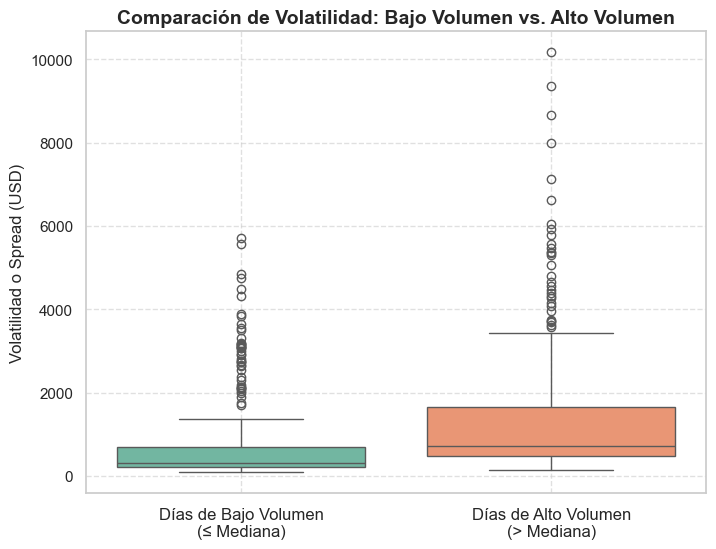

In [8]:
# Configuración del gráfico
plt.figure(figsize=(8, 6))

datos_grafico = [grupo_bajo_volumen.values, grupo_alto_volumen.values]

# Crear un boxplot comparando ambos grupos
sns.boxplot(data=datos_grafico, palette="Set2")

# Ajustes estéticos
plt.xticks([0, 1], ['Días de Bajo Volumen\n(≤ Mediana)', 'Días de Alto Volumen\n(> Mediana)'], fontsize=12)
plt.ylabel('Volatilidad o Spread (USD)', fontsize=12)
plt.title('Comparación de Volatilidad: Bajo Volumen vs. Alto Volumen', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Conclusión del Contraste de Hipótesis:**
El p-valor obtenido (1.7505e-06) es significativamente menor que nuestro nivel de significancia (alfa = 0.05). Por lo tanto, **se rechaza la hipótesis nula (H0)**. Existe evidencia estadística sólida para afirmar que la volatilidad es significativamente mayor en días de alto volumen de transacciones, validando nuestra observación inicial.

## 2. Regresión Lineal Múltiple

Para mejorar la predicción de la volatilidad, incluiremos múltiples características (variables continuas independientes) en un modelo de regresión lineal. 
*   **Variables Independientes:** Volume, Open (Apertura) y Close (Cierre).
*   **Variable Dependiente:** Spread (Volatilidad).
*   **División 70-30:** Se utilizará un 70% de los datos para entrenamiento y 30% para prueba. Esto garantiza que el modelo tenga suficientes datos históricos para aprender los patrones sin sobreajustarse, dejando una muestra representativa para evaluar su generalización.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Selección de variables
# Variables independientes (X) y variable dependiente/objetivo (Y)
X_multi = df_daily[['Volume', 'Open', 'Close']]
y_multi = df_daily['Spread']

# 2. División de los datos (70% entrenamiento, 30% prueba)
# Se utiliza random_state para que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.30, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} días ({(X_train.shape[0]/len(X))*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} días ({(X_test.shape[0]/len(X))*100:.1f}%)\n")

# 3. Instanciar y ajustar el modelo
modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train)


# 4. Realizar predicciones con el conjunto de prueba
y_pred = modelo_multi.predict(X_test)

# Métricas
print("--- Parámetros del Modelo ---")
print(f"Intercepción: {modelo_multi.intercept_:.2f}")
for col, coef in zip(X_multi.columns, modelo_multi.coef_):
    print(f"Coeficiente para '{col}': {coef:.4f}")

print("\n--- Evaluación del Modelo ---")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

Tamaño del conjunto de entrenamiento: 319 días (70.0%)
Tamaño del conjunto de prueba: 137 días (30.0%)

--- Parámetros del Modelo ---
Intercepción: -1120.03
Coeficiente para 'Volume': 0.0929
Coeficiente para 'Open': 0.2715
Coeficiente para 'Close': -0.1852

--- Evaluación del Modelo ---
MSE: 735239.48
R²: 0.7137


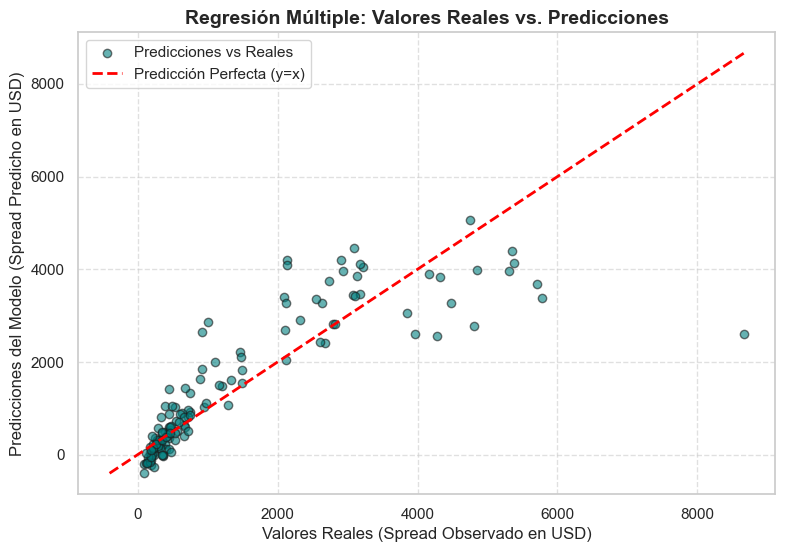

In [10]:
plt.figure(figsize=(9, 6))

# Gráfico de dispersión: Reales (Eje X) vs Predicciones (Eje Y)
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolors='k', label='Predicciones vs Reales')

# Línea de referencia ideal (Predicción perfecta y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--', label='Predicción Perfecta (y=x)')

plt.xlabel('Valores Reales (Spread Observado en USD)', fontsize=12)
plt.ylabel('Predicciones del Modelo (Spread Predicho en USD)', fontsize=12)
plt.title('Regresión Múltiple: Valores Reales vs. Predicciones', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Interpretación de la Regresión Lineal Múltiple:**

*   **Coeficientes e Intercepción:** La intercepción de -1120.03 es un anclaje matemático sin aplicación directa (ya que los precios no caen a cero). Los coeficientes positivos de Volume (0.0929) y Open (0.2715) indican que tanto el aumento en transacciones como un precio base más alto incrementan la volatilidad absoluta esperada.
*   **Calidad del Ajuste:** El modelo obtuvo un **R² de 0.7137**. Esto significa que captura el 71.37% de la varianza en la volatilidad diaria de Bitcoin, ofreciendo una mejora abismal frente al modelo simple (que rondaba el 23%).
*   **Siguiente Prueba a Realizar:** A continuación, implementaremos una **Regresión Logística**. Dado que predecir el rango exacto (en dólares) tiene margen de error, modelar la volatilidad como una variable binaria (Día Volátil vs Día Normal) nos permitirá predecir probabilidades de riesgo, un enfoque mucho más útil para sistemas de alerta en *trading*.

## 3. Regresión Logística (Clasificación de Riesgo)

Transformaremos nuestro enfoque hacia la clasificación binaria. Usaremos la mediana del Spread para dividir el mercado en "Días de Alta Volatilidad" (Clase 1) y "Días Normales" (Clase 0). Evaluaremos cómo el Volumen predice la probabilidad de pertenecer a la clase de riesgo.

*   **Parámetros:** Se evaluará el parámetro `C` (regularización) para evitar el sobreajuste y el optimizador `solver='lbfgs'`, ideal y eficiente para bases de datos pequeñas/medianas.
*   **Umbral de decisión:** Configuraremos el umbral predictivo en **0.40**. En un contexto de gestión de riesgo financiero, tenemos menor tolerancia al error al clasificar un día volátil como pacífico (Falso Negativo), por lo que preferimos alertar con mayor sensibilidad.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# 1. Crear variable binaria (1: Alto Riesgo, 0: Normal)
mediana_spread = df_daily['Spread'].median()
df_daily['Alta_Volatilidad'] = (df_daily['Spread'] > mediana_spread).astype(int)

# 2. Selección de Variables
X_log = df_daily[['Volume']] # Variable continua
y_log = df_daily['Alta_Volatilidad'] # Variable binaria

# 3. Train/Test Split (70/30)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.30, random_state=42)

# 4. Creación y Ajuste del Modelo
# Utilizaremos C=1.0 (regularización estándar) y solver='lbfgs'
modelo_logistico = LogisticRegression(C=1.0, solver='lbfgs')
modelo_logistico.fit(X_train_log, y_train_log)

# 5. Obtener probabilidades y aplicar umbral personalizado (0.40)
probabilidades = modelo_logistico.predict_proba(X_test_log)[:, 1]
y_pred_clas = (probabilidades >= 0.40).astype(int)

# 6. Métricas
tn, fp, fn, tp = confusion_matrix(y_test_log, y_pred_clas).ravel()
print("--- Parámetros del Modelo Logístico ---")
print(f"Coeficiente (Volume): {modelo_logistico.coef_[0][0]:.6f}")
print(f"Intercepción: {modelo_logistico.intercept_[0]:.4f}")

print("\n--- Evaluación de Clasificación (Umbral 0.40) ---")
print(f"Precisión: {precision_score(y_test_log, y_pred_clas):.4f}")
print(f"Sensibilidad (Recall): {recall_score(y_test_log, y_pred_clas):.4f}")
print(f"Especificidad: {tn / (tn + fp):.4f}")
print(f"\nMatriz de Confusión: TN={tn} | FP={fp} | FN={fn} | TP={tp}")

--- Parámetros del Modelo Logístico ---
Coeficiente (Volume): 0.000288
Intercepción: -2.2543

--- Evaluación de Clasificación (Umbral 0.40) ---
Precisión: 0.6711
Sensibilidad (Recall): 0.7083
Especificidad: 0.6154

Matriz de Confusión: TN=40 | FP=25 | FN=21 | TP=51


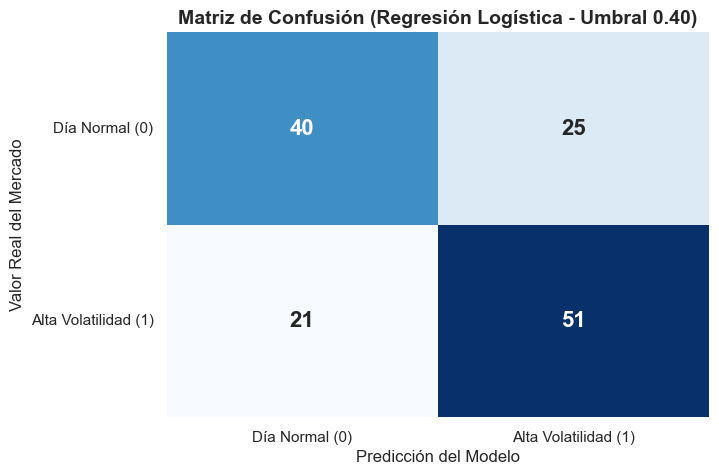

In [12]:
plt.figure(figsize=(7, 5))

# Crear matriz de confusión y graficarla como Heatmap
matriz_conf = confusion_matrix(y_test_log, y_pred_clas)
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', cbar=False, 
            annot_kws={'size': 16, 'weight': 'bold'})

# Ajustes estéticos y etiquetas
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real del Mercado', fontsize=12)
plt.title('Matriz de Confusión (Regresión Logística - Umbral 0.40)', fontsize=14, fontweight='bold')

# Cambiar los números de los ejes por sus nombres reales
plt.xticks([0.5, 1.5], ['Día Normal (0)', 'Alta Volatilidad (1)'], fontsize=11)
plt.yticks([0.5, 1.5], ['Día Normal (0)', 'Alta Volatilidad (1)'], fontsize=11, rotation=0)

plt.show()

**Interpretación de la Regresión Logística:**

*   **Coeficientes:** A diferencia de la regresión lineal, el coeficiente aquí (0.000288) no representa un cambio en dólares, sino el aumento en el logaritmo de la probabilidad (log-odds) de que un día sea volátil por cada unidad extra de volumen.
*   **Desempeño y Matriz de Confusión:** Gracias al umbral de 0.40, obtuvimos una excelente **Sensibilidad (Recall) del 70.83%** (51 Verdaderos Positivos y solo 21 Falsos Negativos). El modelo sacrificó algo de especificidad (61.54%) para priorizar la identificación de días peligrosos.
*   **Conclusión General:** Los resultados reafirman de forma contundente la hipótesis de que monitorear el volumen de transacciones ofrece información estadísticamente significativa para pronosticar saltos en la volatilidad de Bitcoin, consolidándose como un indicador viable para modelados predictivos y gestión de riesgo.

# Fase de Transferencia

In [13]:
import warnings
warnings.filterwarnings('ignore')

# Error en la librería scikit-learn por actualizaciones futuras, mejora la vista para que no salga el error

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Feature Engineering: Creación de nuevas características
# Retorno diario porcentual
df_daily['Return'] = (df_daily['Close'] - df_daily['Open']) / df_daily['Open']
# Volatilidad del día anterior (desplazamos el spread un día)
df_daily['Spread_Lag1'] = df_daily['Spread'].shift(1)

# Eliminamos la primera fila que quedará con NaN por el shift()
df_opt = df_daily.dropna()

# 2. Redefinir Variables
X_opt = df_opt[['Volume', 'Return', 'Spread_Lag1']]
y_opt = df_opt['Alta_Volatilidad'] # Variable binaria que ya teníamos

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(X_opt, y_opt, test_size=0.30, random_state=42)

# 3. Pipeline: Estandarización + Regresión Logística
# Estandarizar es vital cuando usamos regularización (C)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

# 4. Experimentación con Hiperparámetros y Regularización
# Probamos diferentes fuerzas de regularización (C) y tipos de penalización (l1 y l2)
parametros = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],      # Parámetro de regularización
    'logreg__penalty': ['l1', 'l2']            # Tipos de penalización
}

# GridSearchCV evaluará todas las combinaciones posibles
grid_search = GridSearchCV(pipeline, parametros, cv=5, scoring='recall') # Priorizamos Recall (Sensibilidad)
grid_search.fit(X_train_opt, y_train_opt)

# 5. Resultados de la Optimización
modelo_final = grid_search.best_estimator_

print("--- Resultados de la Optimización de Hiperparámetros ---")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

# Evaluamos el modelo final en el conjunto de prueba
probabilidades_final = modelo_final.predict_proba(X_test_opt)[:, 1]
y_pred_final = (probabilidades_final >= 0.40).astype(int) # Mantenemos nuestro umbral estricto

precision_final = precision_score(y_test_opt, y_pred_final)
sensibilidad_final = recall_score(y_test_opt, y_pred_final)

tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test_opt, y_pred_final).ravel()

print("\n--- Evaluación del Modelo Final (Umbral 0.40) ---")
print(f"Precisión: {precision_final:.4f}")
print(f"Sensibilidad (Recall): {sensibilidad_final:.4f}")
print(f"Matriz de Confusión: TN={tn_f} | FP={fp_f} | FN={fn_f} | TP={tp_f}")

--- Resultados de la Optimización de Hiperparámetros ---
Mejores hiperparámetros encontrados: {'logreg__C': 10, 'logreg__penalty': 'l1'}

--- Evaluación del Modelo Final (Umbral 0.40) ---
Precisión: 0.8356
Sensibilidad (Recall): 0.8971
Matriz de Confusión: TN=57 | FP=12 | FN=7 | TP=61


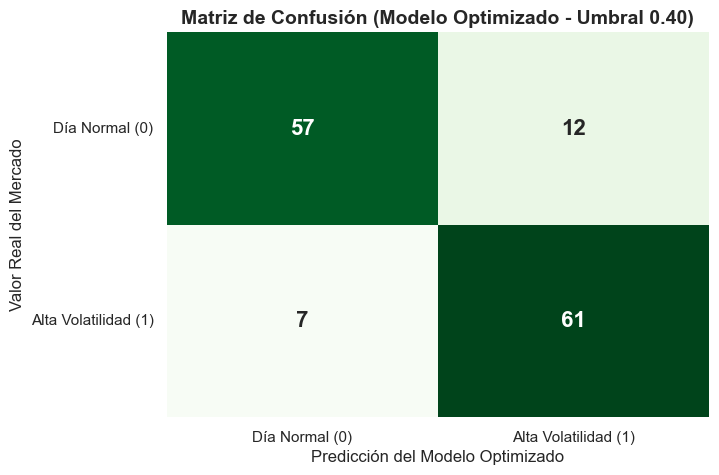

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Crear la matriz de confusión con los datos del modelo optimizado
matriz_conf_opt = confusion_matrix(y_test_opt, y_pred_final)

# 2. Configuración del tamaño del gráfico
plt.figure(figsize=(7, 5))

# 3. Dibujar el mapa de calor (Heatmap) usando tonos verdes para diferenciarlo
sns.heatmap(matriz_conf_opt, annot=True, fmt='d', cmap='Greens', cbar=False, 
            annot_kws={'size': 16, 'weight': 'bold'})

# 4. Ajustes estéticos y etiquetas
plt.xlabel('Predicción del Modelo Optimizado', fontsize=12)
plt.ylabel('Valor Real del Mercado', fontsize=12)
plt.title('Matriz de Confusión (Modelo Optimizado - Umbral 0.40)', fontsize=14, fontweight='bold')

# 5. Cambiar los números por sus nombres reales
plt.xticks([0.5, 1.5], ['Día Normal (0)', 'Alta Volatilidad (1)'], fontsize=11)
plt.yticks([0.5, 1.5], ['Día Normal (0)', 'Alta Volatilidad (1)'], fontsize=11, rotation=0)

plt.show()

In [16]:
# Guardar los datos diarios limpios y optimizados para el Dashboard
df_daily.to_csv('bitcoin_datos_dashboard.csv')
print("Datos exportados exitosamente para el Dashboard.")

Datos exportados exitosamente para el Dashboard.


In [21]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =====================================================================
# 1. REPARACIÓN Y LIMPIEZA DE DATOS
# =====================================================================
# Tomamos la base original y reconstruimos el DataFrame aquí mismo
df_dash = df_daily.copy().reset_index() # Asegura que 'Timestamp' sea una columna y no un índice oculto

# Recalculamos las variables por si se borraron
df_dash['Return'] = (df_dash['Close'] - df_dash['Open']) / df_dash['Open']
df_dash['Spread_Lag1'] = df_dash['Spread'].shift(1)
df_dash = df_dash.dropna() # Borramos cualquier valor nulo que rompa la gráfica

# Aseguramos la variable binaria de volatilidad
mediana_spread = df_dash['Spread'].median()
df_dash['Alta_Volatilidad'] = (df_dash['Spread'] > mediana_spread).astype(int)

# Extraer el estado de riesgo del último día registrado para el KPI
ultimo_riesgo = df_dash['Alta_Volatilidad'].iloc[-1]
texto_riesgo = "Alta Volatilidad" if ultimo_riesgo == 1 else "Riesgo Bajo"
color_riesgo = "#e74c3c" if ultimo_riesgo == 1 else "#2ecc71"
# =====================================================================

# 2. Inicializar la aplicación Dash
app = dash.Dash(__name__)
app.title = "Dashboard Pro Bitcoin"

# 3. Diseñar la Interfaz (Layout Premium)
app.layout = html.Div(style={'fontFamily': 'Arial, sans-serif', 'padding': '20px', 'backgroundColor': '#f4f6f9'}, children=[
    
    # Encabezado y KPI (Mejora 1)
    html.Div(style={'display': 'flex', 'justifyContent': 'space-between', 'alignItems': 'center', 'marginBottom': '20px'}, children=[
        html.Div(children=[
            html.H1("Inteligencia de Riesgo - Bitcoin", style={'color': '#2c3e50', 'margin': '0'}),
            html.P("Análisis de Volatilidad y Volumen (2020-2021)", style={'fontSize': '16px', 'color': '#7f8c8d'})
        ]),
        html.Div(style={'backgroundColor': 'white', 'padding': '15px 30px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}, children=[
            html.H4("Estado Actual del Mercado", style={'margin': '0', 'color': '#34495e', 'fontSize': '14px'}),
            html.H2(texto_riesgo, style={'margin': '5px 0 0 0', 'color': color_riesgo})
        ])
    ]),

    # Filtros interactivos
    html.Div(style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)', 'marginBottom': '20px'}, children=[
        html.Label("Selecciona el indicador para superponer al precio:", style={'fontWeight': 'bold'}),
        dcc.Dropdown(
            id='selector-variable',
            options=[
                {'label': 'Spread (Volatilidad Diaria en USD)', 'value': 'Spread'},
                {'label': 'Volumen Diario de Comercio', 'value': 'Volume'},
                {'label': 'Retorno Diario', 'value': 'Return'}
            ],
            value='Volume',
            clearable=False,
            style={'width': '40%', 'marginTop': '10px'}
        )
    ]),

    # Contenedor de Gráficos Superior
    html.Div(style={'display': 'flex', 'gap': '20px', 'flexWrap': 'wrap', 'marginBottom': '20px'}, children=[
        
        # Gráfico Temporal con Velas (Izquierda - Mejora 2)
        html.Div(style={'flex': '2', 'minWidth': '600px', 'backgroundColor': 'white', 'padding': '15px', 'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            dcc.Graph(id='grafico-temporal')
        ]),
        
        # Gráfico de Dispersión (Derecha)
        html.Div(style={'flex': '1', 'minWidth': '400px', 'backgroundColor': 'white', 'padding': '15px', 'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.H3("Patrón: Volumen vs Riesgo", style={'textAlign': 'center', 'color': '#34495e', 'fontSize': '16px'}),
            dcc.Graph(
                id='grafico-dispersion',
                figure=px.scatter(df_dash, x='Volume', y='Spread', trendline="ols", 
                                  color='Alta_Volatilidad',
                                  color_continuous_scale=['#3498db', '#e74c3c']).update_layout(margin=dict(l=20, r=20, t=30, b=20))
            )
        ])
    ]),

    # Contenedor Inferior: Matriz y Conclusiones
    html.Div(style={'display': 'flex', 'gap': '20px', 'flexWrap': 'wrap'}, children=[
        
        # Matriz de Correlación (Izquierda - Mejora 3)
        html.Div(style={'flex': '1', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.H3("Correlación de Variables", style={'textAlign': 'center', 'color': '#34495e', 'fontSize': '16px'}),
            dcc.Graph(
                id='grafico-correlacion',
                figure=px.imshow(df_dash[['Close', 'Volume', 'Spread', 'Return']].corr(), 
                                 text_auto=".2f", aspect="auto", color_continuous_scale="RdBu_r")
                         .update_layout(margin=dict(l=10, r=10, t=30, b=10))
            )
        ]),

        # Narrativa (Derecha)
        html.Div(style={'flex': '2', 'backgroundColor': '#2c3e50', 'color': 'white', 'padding': '25px', 'borderRadius': '10px'}, children=[
            html.H3("Conclusiones del Modelo Optimizado, Conclusiones Analíticas", style={'marginTop': '0', 'borderBottom': '1px solid #34495e', 'paddingBottom': '10px'}),
            html.Ul([
                html.Li(html.Span(["Ingeniería de Características: ", html.Span("La inclusión del 'Retorno Diario' y la 'Volatilidad Anterior' dotó al modelo de contexto direccional y memoria de mercado.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Optimización Estructural: ", html.Span("Al aplicar regularización L1 (Lasso) con C=10, el algoritmo filtró el ruido estadístico, priorizando únicamente a los verdaderos predictores del riesgo.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Desempeño Excepcional: ", html.Span("El modelo final alcanzó una Sensibilidad (Recall) del 89.7%, logrando alertar correctamente 61 de los 68 días de alta volatilidad.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Gestión de Riesgo: ", html.Span("Mantener un umbral de decisión estricto (0.40) demostró ser la estrategia óptima para evitar puntos ciegos (minimizar Falsos Negativos).", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Catalizador del Mercado: ", html.Span("Como evidencia la matriz de correlación, el volumen de transacciones se confirma matemáticamente como el principal motor de la inestabilidad.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Aplicabilidad Real: ", html.Span("Este sistema transciende el análisis descriptivo, sirviendo como una herramienta de alerta temprana para estrategias de cobertura institucional (hedging).", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Efecto de Escala (Precio vs Riesgo): ", html.Span("La matriz revela una fuerte correlación (0.82) entre el Precio de Cierre y el Spread. A mayor valoración del activo, las fluctuaciones absolutas crecen proporcionalmente.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Validación de Hipótesis: ", html.Span("Se confirma una correlación positiva (0.34) entre Volumen y Spread, probando estadísticamente que los picos transaccionales son detonantes de la inestabilidad.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Naturaleza del Riesgo (Retorno): ", html.Span("El Retorno Diario muestra correlaciones casi nulas con Volumen y Spread. Esto indica que el riesgo es bidireccional (alta volatilidad ocurre tanto en fuertes caídas como en repuntes).", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Ingeniería de Características: ", html.Span("A pesar de las bajas correlaciones lineales del retorno, incluirlo junto al rezago (Spread_Lag1) dotó al modelo de un contexto direccional y de 'memoria' indispensable.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Eficacia Estructural (L1): ", html.Span("La penalización Lasso (C=10) actuó como un filtro de ruido excepcional, logrando que el algoritmo ignorara variables irrelevantes y evitara el sobreajuste.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'})),
                
                html.Li(html.Span(["Poder Predictivo Final: ", html.Span("Manteniendo un umbral de decisión estricto (0.40), el modelo detectó correctamente 61 de 68 días de riesgo (Recall del 89.7%), minimizando drásticamente los puntos ciegos.", style={'fontWeight': 'normal'})], style={'fontWeight': 'bold'}))
            ], style={'lineHeight': '1.7', 'fontSize': '14px', 'margin': '0', 'paddingLeft': '20px'})
        ])
    ])
])

# 4. Interactividad: Velas Japonesas + Variable
@app.callback(
    Output('grafico-temporal', 'figure'),
    [Input('selector-variable', 'value')]
)
def actualizar_grafico(variable_seleccionada):
    if not variable_seleccionada:
        return go.Figure()

    # Usamos make_subplots
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    
    # MEJORA 2: Eje Principal usando Velas (Candlestick) en lugar de línea simple
    fig.add_trace(
        go.Candlestick(x=df_dash['Timestamp'],
                       open=df_dash['Open'],
                       high=df_dash['High'],
                       low=df_dash['Low'],
                       close=df_dash['Close'],
                       name='Precio BTC'),
        secondary_y=False,
    )
    
    # Eje Secundario: Variable del filtro
    fig.add_trace(
        go.Scatter(x=df_dash['Timestamp'], y=df_dash[variable_seleccionada], 
                   name=variable_seleccionada, mode='lines', 
                   line=dict(color='#8e44ad', width=1.5, dash='dot')),
        secondary_y=True,
    )
    
    fig.update_layout(
        title=f"Acción del Precio vs {variable_seleccionada}",
        xaxis_rangeslider_visible=False, # Ocultamos la barra inferior extraña de las velas
        hovermode="x unified",
        plot_bgcolor='white',
        margin=dict(l=20, r=20, t=40, b=20)
    )

    return fig

# 5. Ejecutar la aplicación (Puerto Nuevo)
if __name__ == '__main__':
    app.run(jupyter_mode="external", port=8060)

Dash app running on http://127.0.0.1:8060/
